### Packages

In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import cv2;

### Down Sampling

In [6]:
arr6 = np.arange(0, 36).reshape(6, 6);
print(arr6);
print(arr6.shape)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]
 [24 25 26 27 28 29]
 [30 31 32 33 34 35]]
(6, 6)


In [7]:
arr3 = arr6[::2, ::2]
arr3

array([[ 0,  2,  4],
       [12, 14, 16],
       [24, 26, 28]])

In [8]:
arr2 = arr3[::2, ::2]
arr2

array([[ 0,  4],
       [24, 28]])

In [9]:
arr1 = arr2[::2, ::2]
arr1

array([[0]])

Shape :  (1024, 1024)


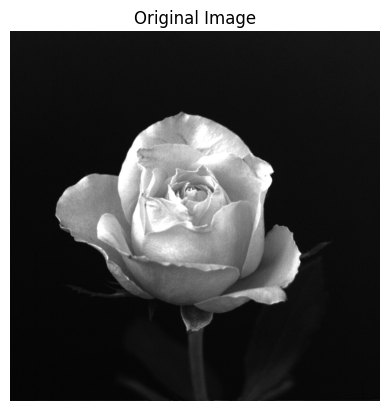

In [10]:
img = cv2.imread("images\Fig0219(rose1024).tif", 0);

print("Shape : ", img.shape);

plt.imshow(img, cmap='gray');
plt.title("Original Image");
plt.axis('off');
plt.show();

In [12]:
# Down sampling the Orginal Image (reducing image resolution)

img512 = img[::2, ::2];
img256 = img512[::2, ::2];
img128 = img256[::2, ::2];
img64 = img128[::2, ::2];

In [13]:
## Showing the results

cv2.imshow("Orginal image", img);
cv2.imshow("512 image", img512);
cv2.imshow("256 image", img256);
cv2.imshow("128 image", img128);
cv2.imshow("64 image", img64);
cv2.waitKey(0);
cv2.destroyAllWindows();

In [14]:
### Check the dimensions for verification

print("Original Image Shape : ", img.shape);
print("512 Image Shape : ", img512.shape);
print("256 Image Shape : ", img256.shape);
print("128 Image Shape : ", img128.shape);
print("64 Image Shape : ", img64.shape);

Original Image Shape :  (1024, 1024)
512 Image Shape :  (512, 512)
256 Image Shape :  (256, 256)
128 Image Shape :  (128, 128)
64 Image Shape :  (64, 64)


### Up Sampling
- Using simple pixel duplication technique
- We will upsample the above downsampled images to original resolution (1024, 1024).

In [15]:
arr = np.array([
    [100, 150, 200],
    [300, 350, 400],
    [500, 550, 600]
])
print("Original Array : \n", arr);

Original Array : 
 [[100 150 200]
 [300 350 400]
 [500 550 600]]


In [16]:
up_arr = np.arange(0, 36).reshape(6, 6);

In [19]:
print(up_arr);
up_arr[1::2, 1::2] = arr;
print("Upsampled Array : \n", up_arr);

[[100 100 150 150 200 200]
 [  6   7   8   9  10  11]
 [300 300 350 350 400 400]
 [ 18  19  20  21  22  23]
 [500 500 550 550 600 600]
 [ 30  31  32  33  34  35]]
Upsampled Array : 
 [[100 100 150 150 200 200]
 [  6 100   8 150  10 200]
 [300 300 350 350 400 400]
 [ 18 300  20 350  22 400]
 [500 500 550 550 600 600]
 [ 30 500  32 550  34 600]]


In [20]:
arr

array([[100, 150, 200],
       [300, 350, 400],
       [500, 550, 600]])

In [22]:
up_arr2 = np.zeros((arr.shape[0]*2, arr.shape[1]*2), dtype=np.uint16);
print(up_arr2);

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [23]:
for i in range(2):
    for j in range(2):
        up_arr2[i::2, j::2] = arr;
print("Upsampled Array : \n", up_arr2);

Upsampled Array : 
 [[100 100 150 150 200 200]
 [100 100 150 150 200 200]
 [300 300 350 350 400 400]
 [300 300 350 350 400 400]
 [500 500 550 550 600 600]
 [500 500 550 550 600 600]]


In [24]:
256*4

1024

In [25]:
img512us = np.zeros((img512.shape[0]*2, img512.shape[1]*2), dtype=np.uint8);
img512us[::2, ::2] = img512;
img512us[0::2, 1::2] = img512;
img512us[1::2, 0::2] = img512;
img512us[1::2, 1::2] = img512;

img256us = np.zeros((img256.shape[0]*4, img256.shape[1]*4), dtype=np.uint8);
for i in range(4):
    for j in range(4):
        img256us[i::4, j::4] = img256;

img128us = np.zeros((img128.shape[0]*8, img128.shape[1]*8), dtype=np.uint8);
for i in range(8):
    for j in range(8):
        img128us[i::8, j::8] = img128;

img64us = np.zeros((img64.shape[0]*16, img64.shape[1]*16), dtype=np.uint8);
for i in range(16):
    for j in range(16):
        img64us[i::16, j::16] = img64;

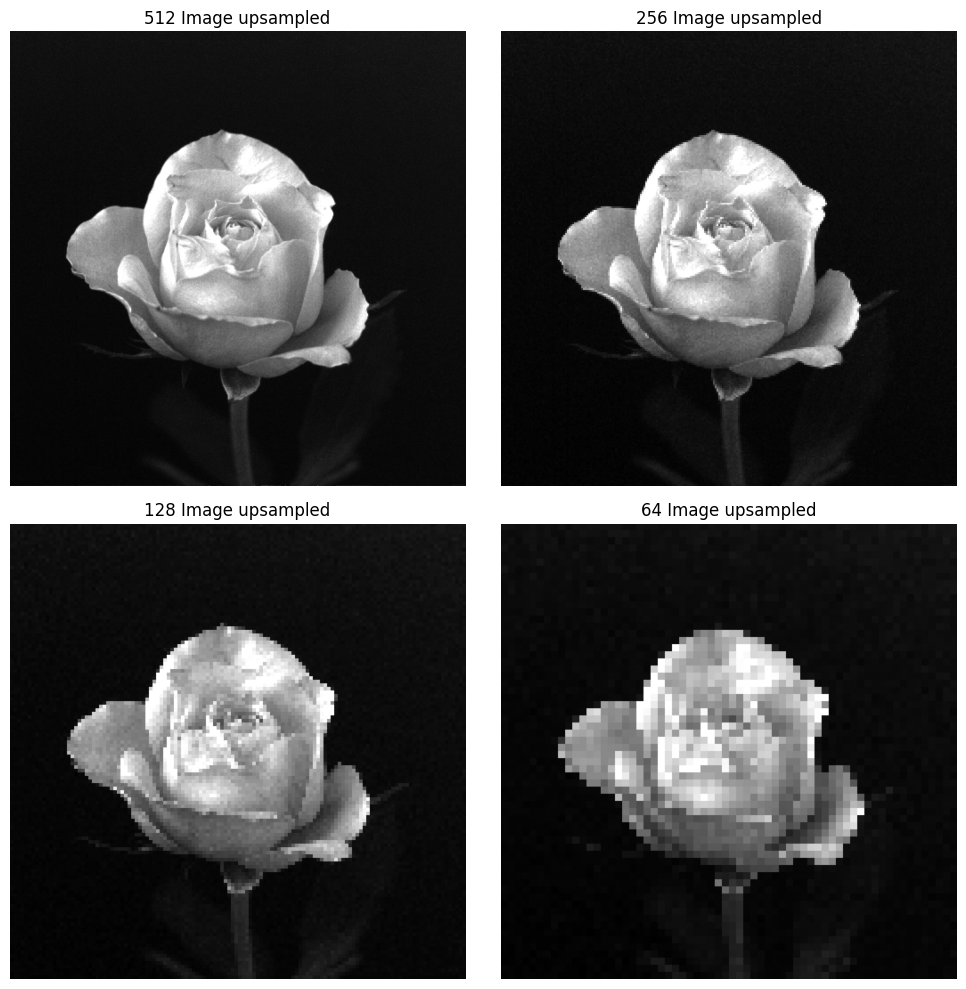

In [26]:
fig, axs = plt.subplots(2,2, figsize=(10, 10));

axs[0,0].imshow(img512us, cmap='gray');
axs[0,0].set_title("512 Image upsampled");
axs[0,0].axis('off');

axs[0,1].imshow(img256us, cmap='gray');
axs[0,1].set_title("256 Image upsampled");
axs[0,1].axis('off');

axs[1,0].imshow(img128us, cmap='gray');
axs[1,0].set_title("128 Image upsampled");
axs[1,0].axis('off');

axs[1,1].imshow(img64us, cmap='gray');
axs[1,1].set_title("64 Image upsampled");
axs[1,1].axis('off');

plt.tight_layout()
plt.show();

### Color Image

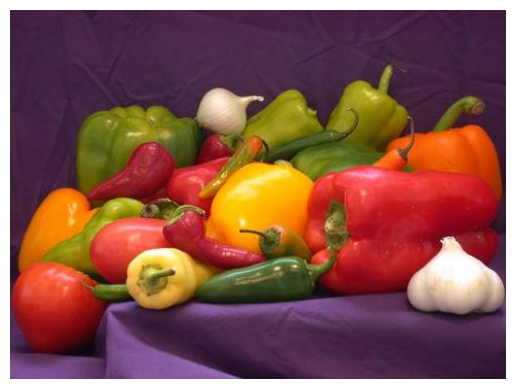

In [27]:
img = plt.imread("images\color_img.jpg");

plt.imshow(img);
plt.axis('off');

In [28]:
redch=img[:, :, 0]
greench=img[:, :, 1]
bluech=img[:, :, 2]


cv2.imshow('Red', redch)
cv2.imshow('green', greench)
cv2.imshow('blue', bluech)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [29]:
ch3img=np.zeros((img.shape[0], img.shape[1], img.shape[2]), dtype=np.uint8)

ch3img[:, :, 0]=greench
ch3img[:, :, 1]=redch
ch3img[:, :, 2]=bluech
cv2.imshow('red', ch3img)
cv2.waitKey(0)
cv2.destroyAllWindows()

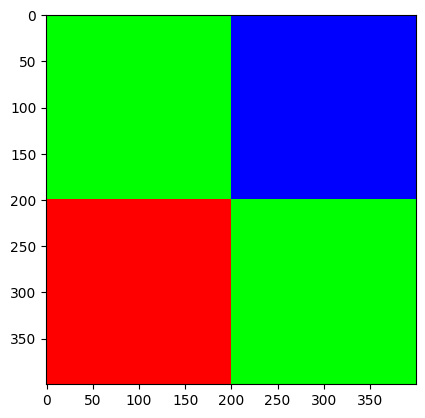

In [30]:
ch3img=np.zeros((400, 400, 3), dtype=np.uint8)

ch3img[200:, :200, 0]=255
ch3img[200:, 200:, 1]=255
ch3img[:200, :200, 1]=255
ch3img[:200, 200:, 2]=255


plt.imshow(ch3img)

In [31]:
# Extracting the red, green, and blue channels from the image.

red_channel = img[:, :, 0];     
green_channel = img[:, :, 1];
blue_channel = img[:, :, 2];

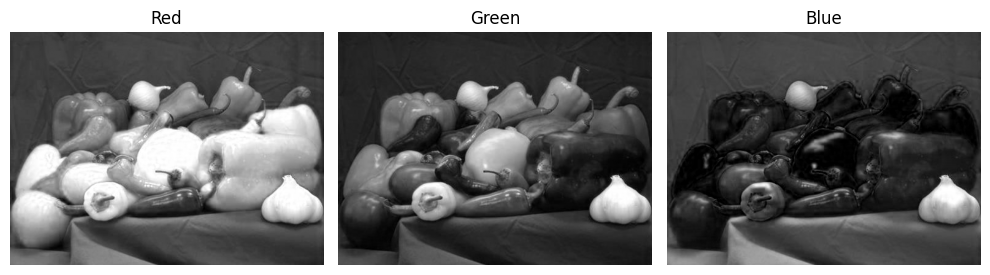

In [32]:
fig, axs = plt.subplots(1,3, figsize=(10,12));

axs[0].imshow(red_channel, 'gray');
axs[0].set_title("Red");
axs[0].axis("off");
axs[1].imshow(green_channel, 'gray');
axs[1].set_title("Green");
axs[1].axis("off");
axs[2].imshow(blue_channel, 'gray');
axs[2].set_title("Blue");
axs[2].axis("off");

plt.tight_layout();
plt.show();

### Image Interpolation

Shape :  (1024, 1024)


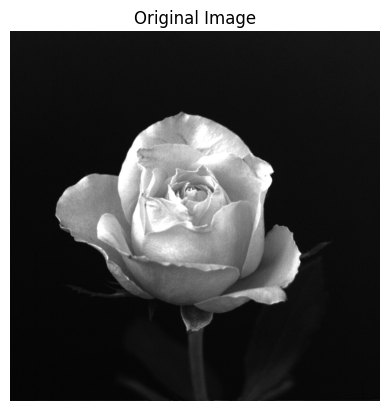

In [3]:
img = cv2.imread(r"images\Fig0219(rose1024).tif", 0);

print("Shape : ", img.shape);
plt.imshow(img, 'gray');
plt.title("Original Image");
plt.axis('off');
plt.show();

#### Steps
- We will first reduce the resolution of the image
- And then apply different interpolation techniques

<ol>
    <li>Nearest Neighbor Interpolation</li>
    <li>Bilinear Interpolation</li>
    <li>Bicubic Interpolation</li>
</ol>

Shape :  (171, 171)


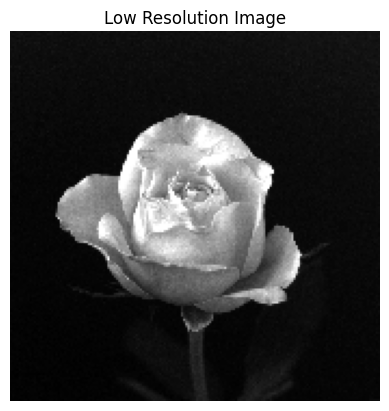

In [4]:
## reduce the resolution of image
red_img = img[::6, ::6];

print("Shape : ", red_img.shape);
plt.imshow(red_img, 'gray');
plt.title("Low Resolution Image");
plt.axis("off");
plt.show();

##### Manual Implementation of Nearest Neighbor

In [5]:
arr = np.array(
    [[100, 200, 300],
     [400, 500, 600],
     [700, 800, 900]]
)

row_scale = 3/6
col_scale = 3/6

nni_arr = np.zeros((6, 6), dtype=np.uint16);

for i in range(nni_arr.shape[0]):
    r = int(i*row_scale);
    for j in range(nni_arr.shape[1]):
        c = int(j * col_scale);
        nni_arr[i,j] = arr[r,c];
print("Original Array : \n", arr);
print("NNI Array : \n", nni_arr);

Original Array : 
 [[100 200 300]
 [400 500 600]
 [700 800 900]]
NNI Array : 
 [[100 100 200 200 300 300]
 [100 100 200 200 300 300]
 [400 400 500 500 600 600]
 [400 400 500 500 600 600]
 [700 700 800 800 900 900]
 [700 700 800 800 900 900]]


In [6]:
### Applying Nearest Neighbor Inerpolation  
## Original Image resolution is (1024, 1024)
## Reduced image resolution is (171, 171)

### Creating an array of original image size filled with zeros
nni_img = np.zeros((1024, 1024), dtype=np.uint8);                  ### Nearest_Neighbor_Interpolated_img


row_scale = 171/1024;
col_scale = 171/1024;

for i in range(nni_img.shape[0]):
    r = int(i*row_scale);
    for j in range(nni_img.shape[1]):
        c = int(j * col_scale);
        nni_img[i,j] = red_img[r,c];       ## Reduced_img

##### Using Built-in Function of cv2 

In [7]:
##nearest_neighbor = cv2.resize(red_img, (2812, 3692), interpolation=cv2.INTER_NEAREST)

bilinear = cv2.resize(red_img, (1024, 1024), interpolation=cv2.INTER_LINEAR)
bicubic = cv2.resize(red_img, (1024, 1024), interpolation=cv2.INTER_CUBIC)

In [8]:
## using cv2 to dispaly images

cv2.imshow("Reduced Image", red_img);
cv2.imshow("NNI", nni_img);
cv2.imshow("Bilinear", bilinear);
cv2.imshow("Bicubic", bicubic);

cv2.waitKey(0);
cv2.destroyAllWindows();

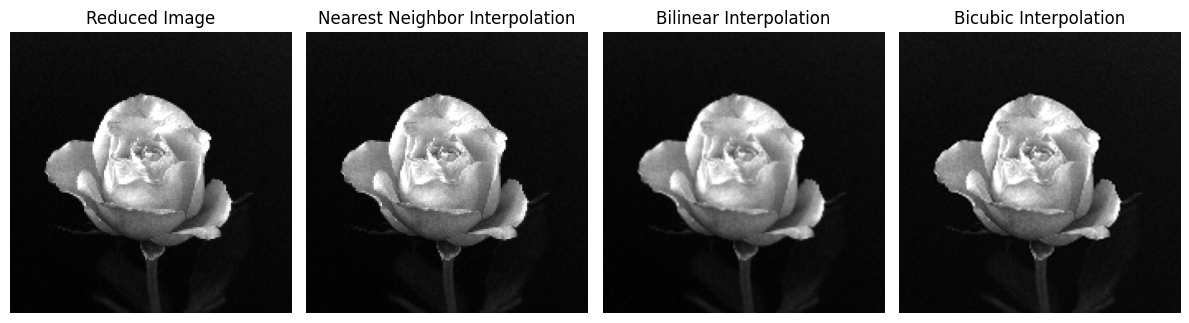

In [9]:
### Showing the result using plt

fig, axs = plt.subplots(1,4, figsize=(12,12));

axs[0].imshow(red_img, cmap='gray');
axs[0].set_title("Reduced Image");
axs[0].axis('off');

axs[1].imshow(nni_img, cmap='gray');
axs[1].set_title("Nearest Neighbor Interpolation");
axs[1].axis('off');

axs[2].imshow(bilinear, cmap='gray');
axs[2].set_title("Bilinear Interpolation");
axs[2].axis('off');

axs[3].imshow(bicubic, cmap='gray');
axs[3].set_title("Bicubic Interpolation");
axs[3].axis('off');

plt.tight_layout()
plt.show();

### ARITHMETIC OPERATIONS

### Image subtraction

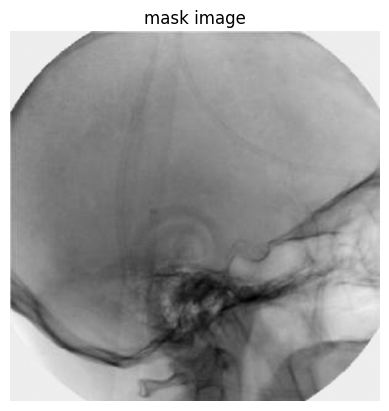

In [10]:
mask_img = cv2.imread("images\Fig0228(a)(angiography_mask_image).tif", 0);

plt.imshow(mask_img, 'gray');
plt.title("mask image");
plt.axis('off');

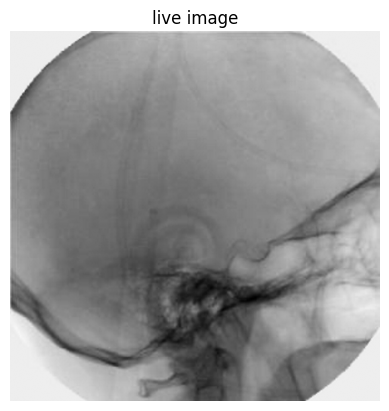

In [11]:
live_img = cv2.imread("images\Fig0228(b)(angiography_live_ image).tif", 0);

plt.imshow(mask_img, 'gray');
plt.title("live image");
plt.axis('off');

In [12]:
result_img = cv2.subtract(mask_img, live_img);

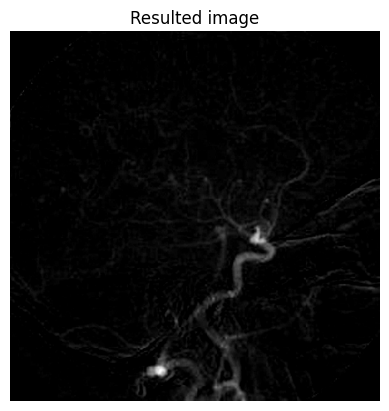

In [13]:
plt.imshow(result_img, 'gray');
plt.title("Resulted image");
plt.axis('off');